In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

df_raw = pd.read_csv("../data/raw/city_day.csv")
df_city = (
    df_raw[df_raw["City"] == "Delhi"]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)
df_city["Date"] = pd.to_datetime(df_city["Date"])

print(f"Total records for Delhi: {len(df_city)}")
df_city.info()

Total records for Delhi: 2009
<class 'pandas.DataFrame'>
RangeIndex: 2009 entries, 0 to 2008
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        2009 non-null   str           
 1   Date        2009 non-null   datetime64[us]
 2   PM2.5       2007 non-null   float64       
 3   PM10        1932 non-null   float64       
 4   NO          2007 non-null   float64       
 5   NO2         2007 non-null   float64       
 6   NOx         2009 non-null   float64       
 7   NH3         2000 non-null   float64       
 8   CO          2009 non-null   float64       
 9   SO2         1899 non-null   float64       
 10  O3          1925 non-null   float64       
 11  Benzene     2009 non-null   float64       
 12  Toluene     2009 non-null   float64       
 13  Xylene      1228 non-null   float64       
 14  AQI         1999 non-null   float64       
 15  AQI_Bucket  1999 non-null   str           
dtypes: da

Missing Value Percentages (%):
 PM2.5          0.10
PM10           3.83
NO             0.10
NO2            0.10
NH3            0.45
SO2            5.48
O3             4.18
Xylene        38.88
AQI            0.50
AQI_Bucket     0.50
dtype: float64


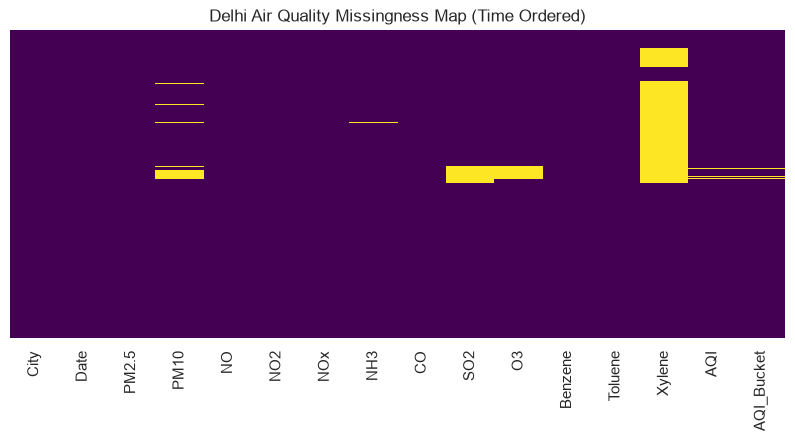

In [2]:
missing = (df_city.isnull().sum() / len(df_city) * 100).round(2)
print("Missing Value Percentages (%):\n", missing[missing > 0])

plt.figure(figsize=(10, 4))
sns.heatmap(
    df_city.isnull(), cbar=False, yticklabels=False, cmap="viridis"
)
plt.title("Delhi Air Quality Missingness Map (Time Ordered)")
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_10812\1283634541.py:21: SyntaxWarning: invalid escape sequence '\m'
  label="Indian NAAQS Safe Threshold (60 $\mu g/m^3$)",
C:\Users\HP\AppData\Local\Temp\ipykernel_10812\1283634541.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu g/m^3$")


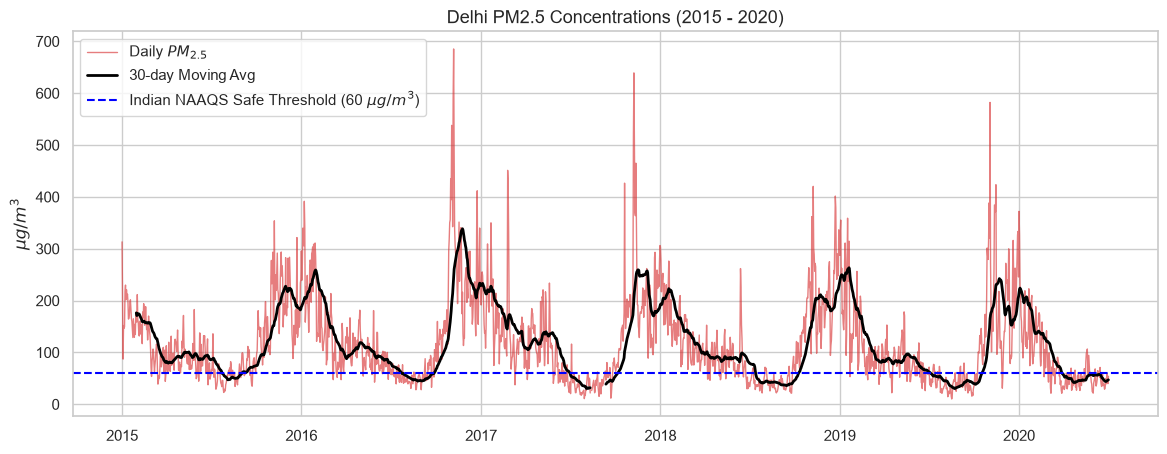

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(
    df_city["Date"],
    df_city["PM2.5"],
    label="Daily $PM_{2.5}$",
    color="#d62728",
    alpha=0.6,
    lw=1,
)
plt.plot(
    df_city["Date"],
    df_city["PM2.5"].rolling(30).mean(),
    label="30-day Moving Avg",
    color="black",
    lw=2,
)
plt.axhline(
    60,
    color="blue",
    linestyle="--",
    label="Indian NAAQS Safe Threshold (60 $\mu g/m^3$)",
)
plt.title("Delhi PM2.5 Concentrations (2015 - 2020)", fontsize=13)
plt.ylabel("$\mu g/m^3$")
plt.legend()
plt.show()

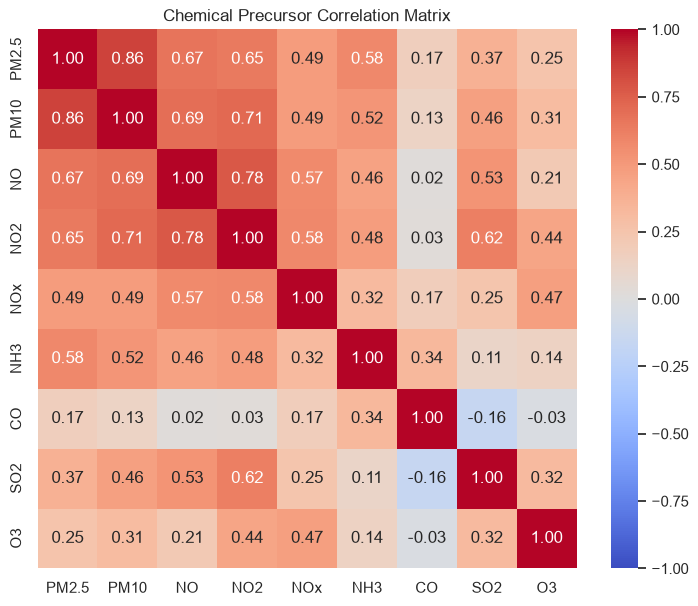

In [4]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
]
corr_matrix = df_city[pollutants].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Chemical Precursor Correlation Matrix")
plt.show()